# Week 10 Exercise // Using the Binomial Distribution + Random Data  
  


The work is divided into two parts:

1. **Using the Binomial Distribution** to evaluate how majority vote improves accuracy in an ensemble of models.
2. **Working with Random Data** by defining a discrete probability mass function (pmf), simulating samples, and analyzing the sampling distribution of the mean.

In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt

# Reproducibility:
# Setting a random seed ensures that any random sampling in this notebook
# produces the same results each time the notebook is run.
np.random.seed(42)

# We will use SciPy if available for clean binomial computations.
# If SciPy is not available, we fall back to a direct summation approach.
try:
    from scipy.stats import binom
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False

def binomial_tail_probability(n, p, k):
    """
    Compute P(X >= k) where X ~ Binomial(n, p).

    Parameters
    ----------
    n : int
        Number of trials (for example, number of models).
    p : float
        Success probability for each trial (for example, single-model accuracy).
    k : int
        Threshold for the tail probability (for example, majority threshold).

    Returns
    -------
    float
        The probability P(X >= k).
    """
    if SCIPY_AVAILABLE:
        # SciPy: P(X >= k) = sf(k-1)
        return binom.sf(k - 1, n, p)

    # Fallback: sum_{x=k..n} [C(n,x) p^x (1-p)^(n-x)]
    total = 0.0
    for x in range(k, n + 1):
        total += math.comb(n, x) * (p ** x) * ((1 - p) ** (n - x))
    return total

print("SciPy available:", SCIPY_AVAILABLE)

SciPy available: True


# Part 1: Using the Binomial Distribution (Majority Vote Ensembles)

## Conceptual setup

Suppose we have an ensemble of `n` independent models, and each model has the same probability `p` of making a correct prediction.

Let:

- `X` represent the number of models (out of `n`) that predict correctly.

Because each model produces a binary outcome (correct or incorrect) and we assume the models are independent, the total number of correct models follows a binomial distribution with `n` trials and success probability `p`.

A majority vote ensemble is correct when more than half of the models are correct. In other words, we calculate the probability that the number of correct models is at least the smallest whole number greater than half of `n`.

## Problem 1(a)

An ensemble contains **15 models**, and each model is correct with probability **0.63**.

Compute the ensemble accuracy under majority voting.

With 15 models, a majority means more than half must be correct. Since half of 15 is 7.5, we need at least 8 correct predictions for the ensemble to be correct.

So we calculate the probability that 8 or more of the 15 models are correct, assuming each model has a 63% chance of being correct and the number of correct models follows a binomial distribution.

In [3]:
n_models = 15
p_single_model = 0.63

# Majority threshold (strictly more than half)
majority_threshold = n_models // 2 + 1  # for 15, this becomes 8

ensemble_accuracy_a = binomial_tail_probability(n_models, p_single_model, majority_threshold)

print("Problem 1(a)")
print("n_models =", n_models)
print("p_single_model =", p_single_model)
print("majority_threshold =", majority_threshold)
print(f"Ensemble accuracy = {ensemble_accuracy_a:.6f} ({ensemble_accuracy_a*100:.2f}%)")

Problem 1(a)
n_models = 15
p_single_model = 0.63
majority_threshold = 8
Ensemble accuracy = 0.851283 (85.13%)


### Interpretation (1a)
This result quantifies the benefit of aggregation. Even though a single model is only 63% accurate, the majority vote of 15 independent models increases the probability of a correct outcome because errors are less likely to dominate the group decision.

## Problem 1(b)

Now keep the ensemble size fixed at 15 models, but find the smallest whole-number percent accuracy for each individual model such that the ensemble accuracy is at least 95%.

Simply, we are searching for the smallest single-model accuracy (in whole percent steps from 50% to 100%) where the probability that at least 8 out of the 15 models are correct is 95% or higher. 

Here, the number of correct models follows a binomial distribution with 15 total models and individual accuracy p.

In [4]:
n_models = 15
majority_threshold = n_models // 2 + 1
target_accuracy = 0.95

best_percent = None
best_ensemble_accuracy = None

for percent in range(50, 101):  # whole-number percentages
    p = percent / 100
    acc = binomial_tail_probability(n_models, p, majority_threshold)

    if acc >= target_accuracy:
        best_percent = percent
        best_ensemble_accuracy = acc
        break

print("Problem 1(b)")
print("Target ensemble accuracy =", target_accuracy)
print("Smallest whole-number percent p =", best_percent, "%")
print(f"Ensemble accuracy at p = {best_percent}% is {best_ensemble_accuracy:.6f} ({best_ensemble_accuracy*100:.2f}%)")

Problem 1(b)
Target ensemble accuracy = 0.95
Smallest whole-number percent p = 71 %
Ensemble accuracy at p = 71% is 0.958655 (95.87%)


### Interpretation (1b)
This result describes how strong each individual model must be, at minimum, for a 15-model majority vote ensemble to reach 95% reliability. It highlights that there is a threshold effect: small increases in individual accuracy can produce large increases in ensemble accuracy once the group vote becomes consistently dominated by correct predictions.

## Problem 1(c)

Now return to the original single-model accuracy of **p = 0.63**, but increase the number of models.

Find the **smallest odd number of models** required for the ensemble accuracy to reach **95%**.

We restrict to odd `n` to avoid ties in majority voting.

In plain language, for each odd value of `n`, we calculate the probability that a majority of the models are correct. A majority means more than half, so the threshold is the smallest whole number greater than `n/2`. We keep increasing `n` until that probability reaches 95% or higher.

In [5]:
# Single model accuracy stays at 63%
p_single_model = 0.63

# We want the ensemble (majority vote) to be at least 95% accurate
target_accuracy = 0.95

# These will store the first n that works
best_n = None
best_acc = None

# Check odd numbers only to avoid ties in majority voting
for n_models in range(1, 1001, 2):

    # Majority means more than half must be correct
    majority_threshold = n_models // 2 + 1

    # Compute probability that at least this many models are correct
    acc = binomial_tail_probability(n_models, p_single_model, majority_threshold)

    # Stop as soon as we hit 95% or higher
    if acc >= target_accuracy:
        best_n = n_models
        best_acc = acc
        break

print("Problem 1(c)")
print("p_single_model =", p_single_model)
print("Target ensemble accuracy =", target_accuracy)
print("Smallest odd n =", best_n)
print(f"Ensemble accuracy at n = {best_n} is {best_acc:.6f} ({best_acc*100:.2f}%)")

Problem 1(c)
p_single_model = 0.63
Target ensemble accuracy = 0.95
Smallest odd n = 39
Ensemble accuracy at n = 39 is 0.951832 (95.18%)


## Part 1 Summary

Part 1 really highlights a few important takeaways:

- A majority vote ensemble can significantly improve reliability, even if each individual model is only moderately accurate.

- There is a clear threshold effect when the number of models is fixed. Each model has to be accurate enough for the group decision to consistently land on the correct side.

- If individual models are not extremely strong, you can still reach high overall accuracy by increasing the number of models. It just requires more of them. There is a tradeoff between model quality and model quantity.

# Part 2: Working with Random Data (Discrete pmf and Sampling Distribution)

## Conceptual setup

Let `X` be a discrete random variable that can take the values 1 through 5.

A probability mass function (pmf) assigns a probability to each possible value of `X`. For it to be valid, two things must be true:

1. Every probability must be nonnegative.
2. All probabilities must add up to 1.

After defining a valid pmf, we will simulate repeated random samples, compute the sample mean each time, and then look at how those means are distributed.

In [11]:
x_values = np.array([1, 2, 3, 4, 5])

# Example probability distribution for X
# These probabilities must be nonnegative and add up to 1
pmf = np.array([0.10, 0.15, 0.30, 0.25, 0.20])

# Basic checks to confirm this is a valid pmf
assert len(x_values) == len(pmf), "Each value needs a matching probability."
assert np.all(pmf >= 0), "Probabilities cannot be negative."
assert np.isclose(pmf.sum(), 1.0), "Probabilities must sum to 1."

print("PMF looks valid.")
print("x_values:", x_values)
print("pmf:", pmf)
print("Sum of probabilities:", pmf.sum())

PMF looks valid.
x_values: [1 2 3 4 5]
pmf: [0.1  0.15 0.3  0.25 0.2 ]
Sum of probabilities: 1.0


## Problem 2(b)
Create a function that:

- randomly generates 50 values of `X` using the pmf
- returns the sample mean of those 50 values

This function represents one simulated experiment of drawing a sample and computing an average.

In [12]:
def draw_sample_and_mean(x_values, pmf, sample_size=50):
    # Generate a random sample of size 50 from X using the pmf
    sample = np.random.choice(x_values, size=sample_size, p=pmf)
    
    # Return the average of that sample
    return sample.mean()

# Quick test run
demo_mean = draw_sample_and_mean(x_values, pmf, sample_size=50)
print("One simulated sample mean (n=50):", demo_mean)

One simulated sample mean (n=50): 3.56


## Problem 2(c)

Now repeat the sample-mean experiment 1,000 times and store each result in a list or array.

Each run gives one sample mean. When we collect all 1,000 of them, we create a distribution of sample means. This is the sampling distribution, which we can then analyze and visualize.

In [13]:
def simulate_means(x_values, pmf, sample_size=50, trials=1000):
    # Create an empty array to store each sample mean
    means = np.zeros(trials)

    # Repeat the sampling process many times
    for i in range(trials):
        means[i] = draw_sample_and_mean(x_values, pmf, sample_size)

    return means

# Run 1,000 trials
means_list = simulate_means(x_values, pmf, sample_size=50, trials=1000)

print("Trials completed:", len(means_list))
print("First 10 sample means:", means_list[:10])

Trials completed: 1000
First 10 sample means: [3.1  3.08 3.28 3.62 2.94 3.1  3.16 3.3  3.84 3.4 ]


## Problem 2(d)

Plot a histogram of the 1,000 sample means.

### Expected shape and theorem

The histogram of the sample means should look roughly bell-shaped.

This happens because of the Central Limit Theorem. When we repeatedly take averages of reasonably large samples (like 50 values at a time), the distribution of those averages starts to look normal, even if the original variable itself is not normally distributed.

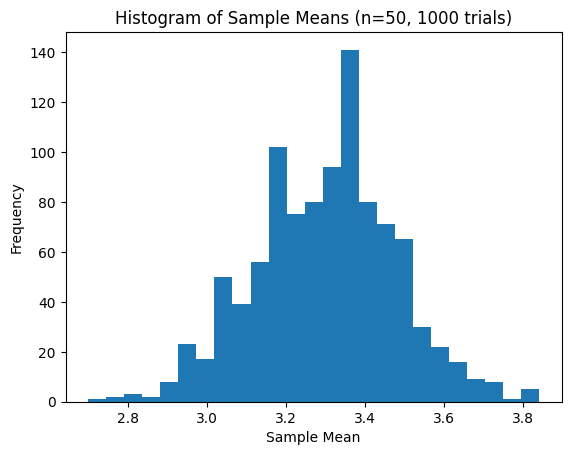

In [15]:
# Plot the distribution of the 1,000 sample means
plt.figure()

# bins controls how detailed the histogram looks
plt.hist(means_list, bins=25)

plt.title("Histogram of Sample Means (n=50, 1000 trials)")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")

plt.show()

## Problem 2(e)

Compute the mean and standard deviation of the sample means, then compare them to the theoretical values.

### Theoretical relationships

- The average of the sample means should be close to the true expected value of `X`.  
- The spread of the sample means should be smaller than the spread of `X`, because averaging reduces variability. Specifically, the standard deviation of the sample means should be the standard deviation of `X` divided by the square root of the sample size.

So the plan is:
1. Compute the empirical mean and standard deviation from the 1,000 simulated sample means.
2. Compute the theoretical expected value and standard deviation of `X` from the pmf.
3. Convert that into the theoretical standard deviation of the sample mean and compare.

In [17]:
sample_size = 50

# Empirical values from the 1,000 simulated sample means
empirical_mean = means_list.mean()
empirical_std = means_list.std(ddof=1)  # use sample standard deviation

# Compute theoretical expected value of X
EX = np.sum(x_values * pmf)

# Compute theoretical variance of X
EX2 = np.sum((x_values ** 2) * pmf)
VarX = EX2 - EX**2
SDX = math.sqrt(VarX)

# Theoretical values for the sample mean
theoretical_mean = EX
theoretical_std = SDX / math.sqrt(sample_size)

print("Empirical results from simulation")
print("Mean of sample means:", round(empirical_mean, 4))
print("Std dev of sample means:", round(empirical_std, 4))
print()
print("Theoretical results")
print("E[X]:", round(theoretical_mean, 4))
print("SD of sample mean:", round(theoretical_std, 4))

Empirical results from simulation
Mean of sample means: 3.2996
Std dev of sample means: 0.1781

Theoretical results
E[X]: 3.3
SD of sample mean: 0.1738


### Interpretation (Part 2)

The average of the 1,000 sample means is very close to the true expected value of X. That is exactly what we would expect from probability theory when we repeatedly take averages.

The standard deviation of the sample means is also close to the theoretical value we calculated. This makes sense because averaging reduces variability. The results line up with what the Central Limit Theorem predicts and show that the simulation is behaving the way the theory says it should.